In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

In [19]:
stocks = []
risk_free_rate = float(input('Enter a suitable risk-free-rate(%): '))
risk_free_rate = risk_free_rate/100
while True:
    answer = input('Enter a stock(Q to quit): ')
    if answer.upper() == 'Q':
        break
    else:
        stocks.append(answer.upper())

data = yf.download(stocks, start = "1900-01-01")
data = data['Close']
data2 =pd.DataFrame()
for i in stocks:
    data2[i] = data[i]
daily_change = np.log(data2.div(data2.shift(1))).dropna()
data2.dropna(inplace=True)


Enter a suitable risk-free-rate(%): 3
Enter a stock(Q to quit): qqqm
Enter a stock(Q to quit): schd
Enter a stock(Q to quit): ko
Enter a stock(Q to quit): q


/tmp/ipython-input-1658848331.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start = "1900-01-01")
[*********************100%***********************]  3 of 3 completed


<Axes: >

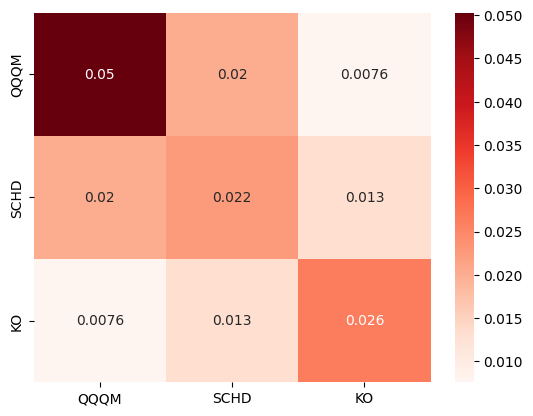

In [20]:
cov_matrix = daily_change.cov()*252
sns.heatmap(cov_matrix,annot=True,cmap='Reds')

In [21]:
for i in stocks:
    data[f'{i} daily_returns'] = np.log(data[i].div(data[i].shift(1)))
    data[f'{i} cummulative_returns'] = data[f'{i} daily_returns'].cumsum().apply(np.exp)
    data[f'{i} cummulative_max'] = data[f'{i} cummulative_returns'].cummax()
    data[f'{i} max drawdown'] = (data[f'{i} cummulative_max'] - data[f'{i} cummulative_returns'])
    data[f'{i} max drawdown in percent'] = data[f'{i} max drawdown']/data[f'{i} cummulative_max']
data.dropna(inplace=True)
data


Ticker,KO,QQQM,SCHD,QQQM daily_returns,QQQM cummulative_returns,QQQM cummulative_max,QQQM max drawdown,QQQM max drawdown in percent,SCHD daily_returns,SCHD cummulative_returns,SCHD cummulative_max,SCHD max drawdown,SCHD max drawdown in percent,KO daily_returns,KO cummulative_returns,KO cummulative_max,KO max drawdown,KO max drawdown in percent
Date,,,,,,,,,,,,,,,,,,
2020-10-14,42.785168,116.051582,16.149395,-0.008962,0.991078,0.991078,0.000000,0.000000,-0.000514,3.043263,3.070392,0.027129,0.008836,-0.001993,949.683555,1110.293548,160.609993,0.144655
2020-10-15,42.674194,115.216766,16.232454,-0.007219,0.983949,0.991078,0.007129,0.007193,0.005130,3.058915,3.070392,0.011477,0.003738,-0.002597,947.220328,1110.293548,163.073220,0.146874
2020-10-16,42.708336,114.629593,16.260139,-0.005109,0.978934,0.991078,0.012144,0.012253,0.001704,3.064132,3.070392,0.006260,0.002039,0.000800,947.978153,1110.293548,162.315395,0.146191
2020-10-19,42.358330,112.646561,16.052494,-0.017451,0.961999,0.991078,0.029079,0.029341,-0.012852,3.025002,3.070392,0.045390,0.014783,-0.008229,940.209221,1110.293548,170.084327,0.153189
2020-10-20,42.896137,113.072174,16.096792,0.003771,0.965634,0.991078,0.025444,0.025673,0.002756,3.033350,3.070392,0.037042,0.012064,0.012617,952.146697,1110.293548,158.146851,0.142437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,70.209999,254.929993,27.620001,0.004533,2.177097,2.232839,0.055743,0.024965,0.005810,5.204834,5.305302,0.100468,0.018937,0.002139,1558.420478,1611.692257,53.271779,0.033053
2025-12-23,69.870003,256.179993,27.540001,0.004891,2.187771,2.232839,0.045068,0.020184,-0.002901,5.189759,5.305302,0.115544,0.021779,-0.004854,1550.873729,1611.692257,60.818528,0.037736
2025-12-24,70.110001,256.869995,27.660000,0.002690,2.193664,2.232839,0.039175,0.017545,0.004348,5.212372,5.305302,0.092930,0.017517,0.003429,1556.200856,1611.692257,55.491401,0.034431


average QQQM returns per year is 16.23359791378549%
average QQQM standard deviation per year is 22.42300111457678%
max drawdown in nominal terms of QQQM is 0.4832826634838082
max drawdown in percentage terms of QQQM is 35.04380472046676%
average SCHD returns per year is 10.881704546717309%
average SCHD standard deviation per year is 14.982669089125892%
max drawdown in nominal terms of SCHD is 0.8554712035251439
max drawdown in percentage terms of SCHD is 16.844308508630572%
average KO returns per year is 9.95526389107253%
average KO standard deviation per year is 16.241024133697422%
max drawdown in nominal terms of KO is 240.55085313581935
max drawdown in percentage terms of KO is 18.151786916772835%


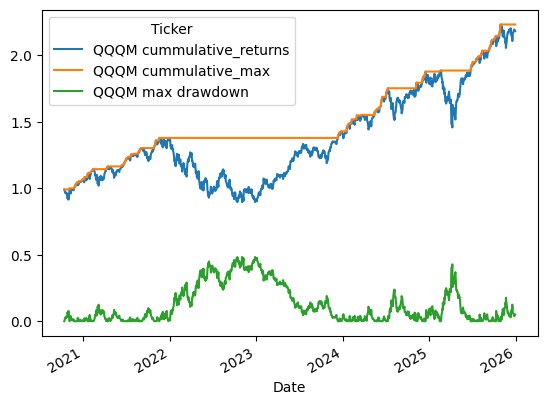

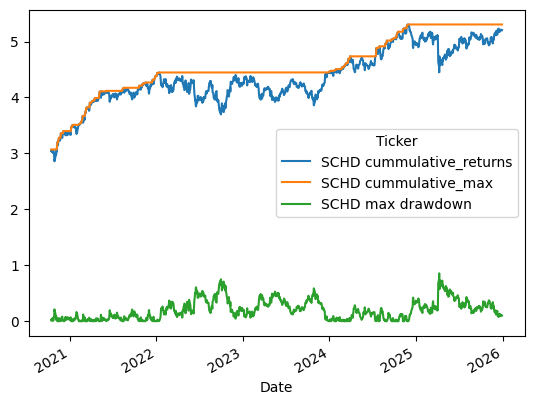

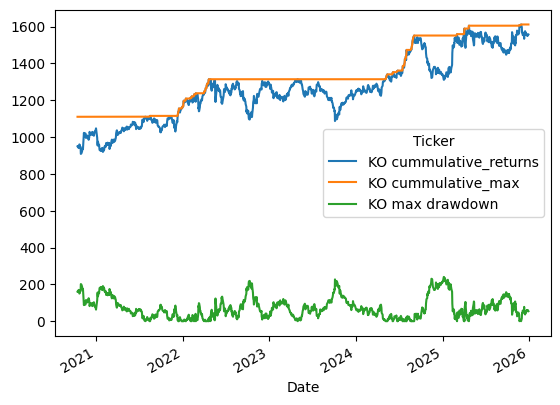

In [22]:
for i in stocks:
    data.loc[:,[f'{i} cummulative_returns',f'{i} cummulative_max',f'{i} max drawdown']].plot()
    summary = data.describe().T.loc[(f'{i} daily_returns'),['mean','std']]
    summary.to_frame()
    print(f'average {i} returns per year is {(np.exp(summary['mean']*252)-1)*100}%')
    summary2 = data.describe().T.loc[[f'{i} max drawdown',f'{i} max drawdown in percent'],'max']
    print(f'average {i} standard deviation per year is {summary['std']*np.sqrt(252)*100}%')
    print(f'max drawdown in nominal terms of {i} is {summary2[f'{i} max drawdown']}')
    print(f'max drawdown in percentage terms of {i} is {summary2[f'{i} max drawdown in percent']*100}%')






In [23]:
weights = np.array([1/len(stocks)]*len(stocks))
weights

array([0.33333333, 0.33333333, 0.33333333])

In [24]:
def standard_deviation (weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)
standard_deviation(weights,cov_matrix)

np.float64(0.14171108681831315)

In [25]:
def expected_returns(weights,daily_change):
    return np.sum((daily_change.mean()*weights*252))
expected_returns(weights, daily_change)

np.float64(0.11620962757495543)

In [26]:
def sharpe_ratio(weights, risk_free_rate,daily_change,cov_matrix):
    return (expected_returns(weights,daily_change)-risk_free_rate)/standard_deviation(weights,cov_matrix)
sharpe_ratio(weights,risk_free_rate,daily_change,cov_matrix)

np.float64(0.6083477976954916)

In [27]:
def negative_sharpe_ratio(weights,risk_free_rate, daily_change,cov_matrix):
    return -sharpe_ratio(weights,risk_free_rate, daily_change,cov_matrix)
negative_sharpe_ratio(weights,risk_free_rate,daily_change,cov_matrix)

np.float64(-0.6083477976954916)

In [28]:
bounds = [(0, 0.5) for _ in range(len(stocks))]
constraints = {'type':'eq','fun':lambda weights: np.sum(weights)-1}

In [29]:
optimized_results = minimize(negative_sharpe_ratio,weights,args=(risk_free_rate,daily_change,cov_matrix),method = 'SLSQP', constraints=constraints, bounds=bounds)

In [30]:
optimal_weights = optimized_results.x
optimal_weights

array([0.46140414, 0.14972554, 0.38887031])

In [31]:
print('OPTIMAL WEIGHTS')
for stock, weights in zip(stocks,optimal_weights):
    print(f'{stock}:{weights}')

optimal_portfolio_return = expected_returns(optimal_weights, daily_change)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, risk_free_rate, daily_change,cov_matrix)

print(f'Expected portfolio return: {optimal_portfolio_return}')
print(f'Expected volatility: {optimal_portfolio_volatility:.4f}')
print(f'Sharpe ratio: {optimal_sharpe_ratio:.4f}')

OPTIMAL WEIGHTS
QQQM:0.46140414482310416
SCHD:0.14972554400863683
KO:0.38887031116825893
Expected portfolio return: 0.12178066087144268
Expected volatility: 0.1491
Sharpe ratio: 0.6156


<BarContainer object of 3 artists>

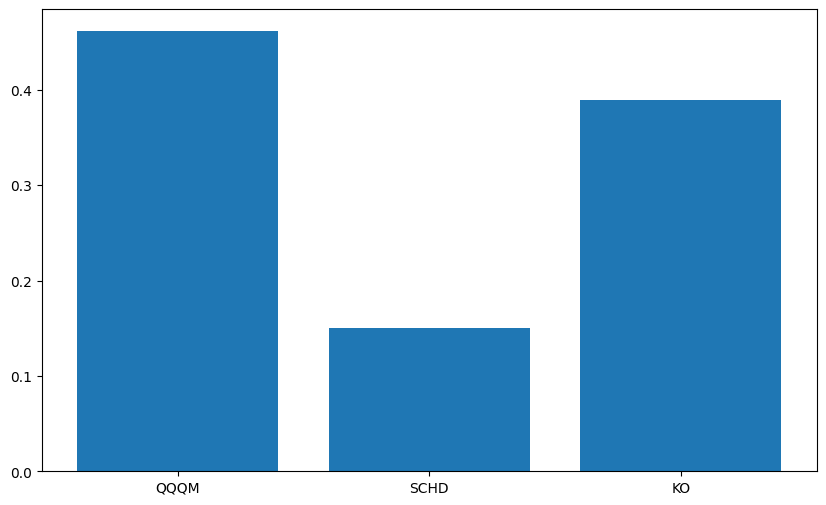

In [32]:
plt.figure(figsize=(10,6))
plt.bar(stocks,optimal_weights)


In [33]:
benchmark = yf.download('SPY', start = "1900-01-01")
benchmark = benchmark['Close']
benchmark['daily_return'] = np.log(benchmark.div(benchmark.shift(1)))
benchmark['average_return_of_benchmark_per_year'] = np.exp(benchmark['daily_return'].mean()*252)-1
benchmark['average_std_of_benchmark_per_year'] = benchmark['daily_return'].std()*np.sqrt(252)
benchmark['cummulative_return'] = benchmark['daily_return'].cumsum().apply(np.exp)
benchmark['strategy_daily_return'] = optimal_portfolio_return/252
benchmark['strategy_cummulative_return'] = benchmark['strategy_daily_return'].cumsum().apply(np.exp)
benchmark['strategy_std'] = optimal_portfolio_volatility
benchmark

/tmp/ipython-input-3869679718.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark = yf.download('SPY', start = "1900-01-01")
[*********************100%***********************]  1 of 1 completed


Ticker,SPY,daily_return,average_return_of_benchmark_per_year,average_std_of_benchmark_per_year,cummulative_return,strategy_daily_return,strategy_cummulative_return,strategy_std
Date,,,,,,,,
1993-01-29,24.241404,NaN,0.107116,0.186439,NaN,0.000483,1.000483,0.149081
1993-02-01,24.413811,0.007087,0.107116,0.186439,1.007112,0.000483,1.000967,0.149081
1993-02-02,24.465548,0.002117,0.107116,0.186439,1.009246,0.000483,1.001451,0.149081
1993-02-03,24.724180,0.010516,0.107116,0.186439,1.019915,0.000483,1.001935,0.149081
1993-02-04,24.827612,0.004175,0.107116,0.186439,1.024182,0.000483,1.002419,0.149081
...,...,...,...,...,...,...,...,...
2025-12-22,684.830017,0.006211,0.107116,0.186439,28.250428,0.000483,54.725571,0.149081
2025-12-23,687.960022,0.004560,0.107116,0.186439,28.379546,0.000483,54.752024,0.149081
2025-12-24,690.380005,0.003511,0.107116,0.186439,28.479374,0.000483,54.778490,0.149081


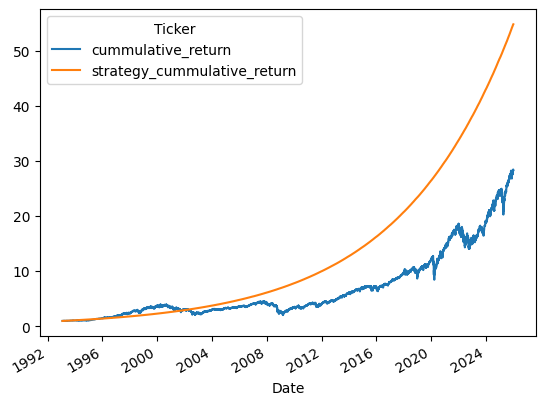

In [34]:
benchmark.loc[:,['cummulative_return','strategy_cummulative_return']].plot()
plt.show()